# Demo 1: Word-Level Interactions in Sentiment Classification

## Research Question
Standard Shapley values tell you *which words* matter individually.
But sentiment is compositional:
- "not bad" is positive — but "not" alone scores near zero
- "absolutely terrible" is stronger than either word alone
- "what a great disaster" is sarcastic

**Can k-SII interactions capture what first-order SVs miss?**

## Setup
- Model: `lvwerra/distilbert-imdb` (DistilBERT fine-tuned on IMDb)
- Players: words (whitespace split)
- Index: SV (baseline) vs k-SII order 2 (interactions)

In [26]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import shapiq
from shapiq.imputer import TextImputer
from shapiq.plot import sentence_plot, sentence_interaction_heatmap

RANDOM_STATE = 42
MODEL_NAME = "lvwerra/distilbert-imdb"

## Example 1: Simple Positive Sentence (Baseline Check)
Before tackling complex phenomena, we verify the pipeline works end-to-end
on a simple unambiguous sentence. We expect "loved" and "amazing" to dominate.

In [27]:
text_pos = "I really loved this amazing film"

imputer_pos = TextImputer(
    MODEL_NAME,
    text_pos,
    segmentation="word",
    mask_strategy="mask",
)

words_pos = imputer_pos.players.tolist()
print(f"Text     : {text_pos}")
print(f"Players  : {words_pos}")
print(f"N players: {imputer_pos.n_features}")
print(f"Empty prediction (baseline): {imputer_pos.normalization_value:.4f}")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Text     : I really loved this amazing film
Players  : ['I', 'really', 'loved', 'this', 'amazing', 'film']
N players: 6
Empty prediction (baseline): 0.5241


### Step 1: First-order Shapley Values
Compute individual word attributions as our baseline.
Budget of 200 is sufficient for 6 players (2^6 = 64 possible coalitions).

In [28]:
approx_sv = shapiq.KernelSHAP(n=imputer_pos.n_features, random_state=RANDOM_STATE)
sv_pos = approx_sv.approximate(budget=200, game=imputer_pos)

print("Shapley Values:")
for word, val in zip(words_pos, sv_pos.values):
    print(f"  {word:12s}: {val:+.4f}")

/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Shapley Values:
  I           : +0.0000
  really      : +0.0312
  loved       : +0.0808
  this        : +0.1179
  amazing     : +0.0314
  film        : +0.1788


In [41]:
fig, ax = sv_pos.plot_sentence(words=words_pos, show=False)
fig.suptitle("Example 1: SV  'I really loved this amazing film'", fontsize=11)
fig.tight_layout()
fig.savefig("sv_pos_sentence.png", dpi=150, bbox_inches="tight")
fig.show()

/var/folders/qr/_165pyzd2_d3dr_cj860yr3c0000gn/T/ipykernel_8284/3472481019.py:3: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/qr/_165pyzd2_d3dr_cj860yr3c0000gn/T/ipykernel_8284/3472481019.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


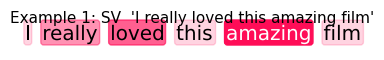

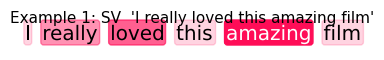

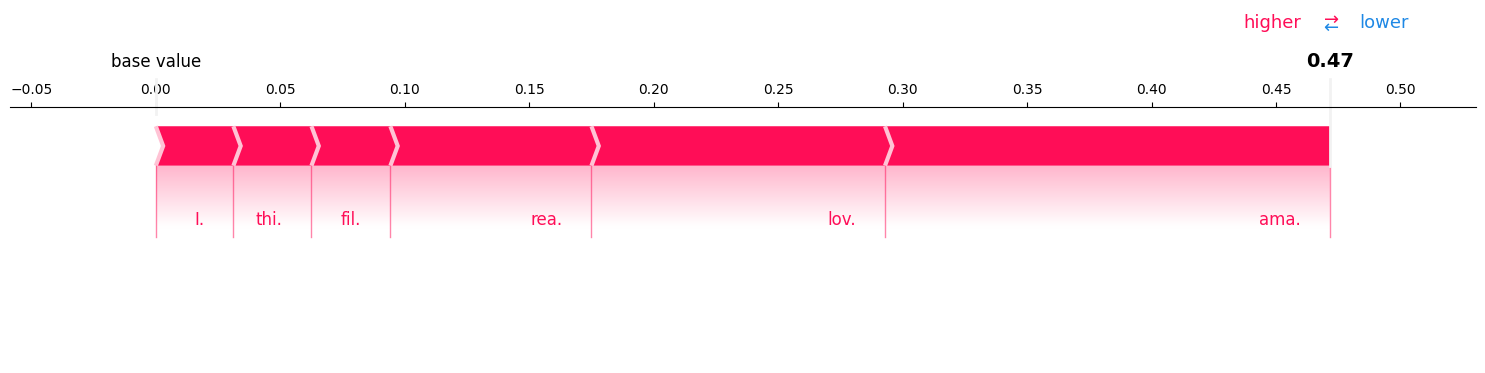

In [42]:
sv_pos.plot_force(feature_names=words_pos)

### Step 2: k-SII Pairwise Interactions (order 2)
Now we ask: which *pairs* of words interact to reinforce or suppress sentiment?
A positive interaction means two words together contribute *more* than their
individual SVs would predict. A negative interaction means they partially
cancel each other out.

In [31]:
approx_sii = shapiq.KernelSHAPIQ(
    n=imputer_pos.n_features,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
)
sii_pos = approx_sii.approximate(budget=200, game=imputer_pos)

print("Top pairwise interactions:")
# extract only order-2 interactions
order2 = {k: v for k, v in sii_pos.interaction_lookup.items() if len(k) == 2}
sorted_interactions = sorted(order2.items(), key=lambda x: abs(sii_pos.values[x[1]]), reverse=True)
for indices, idx in sorted_interactions[:5]:
    w1, w2 = words_pos[indices[0]], words_pos[indices[1]]
    val = sii_pos.values[idx]
    print(f"  ({w1:10s}, {w2:10s}): {val:+.4f}")

/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Top pairwise interactions:
  (loved     , amazing   ): -0.1871
  (really    , amazing   ): -0.1297
  (really    , loved     ): -0.0688
  (this      , amazing   ): -0.0498
  (amazing   , film      ): -0.0489


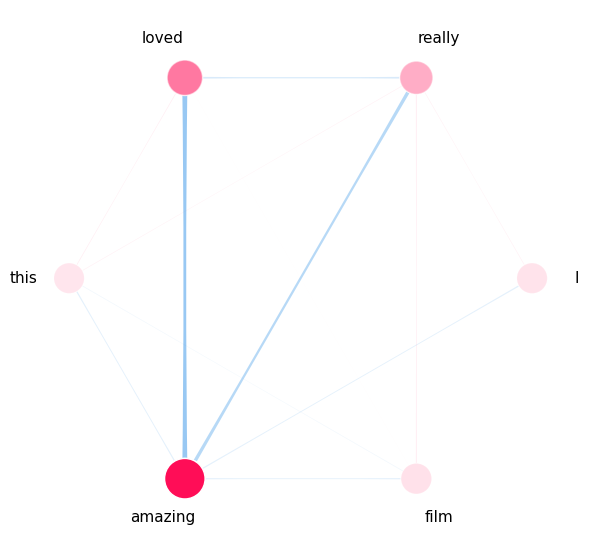

/var/folders/qr/_165pyzd2_d3dr_cj860yr3c0000gn/T/ipykernel_8284/3749536096.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [32]:
# Interaction network
sii_pos.plot_network(feature_names=words_pos)
# Interaction heatmap
from shapiq.plot import sentence_interaction_heatmap

fig, ax = sentence_interaction_heatmap(sii_pos, words_pos, show=False)
fig.suptitle("k-SII Interaction Heatmap — 'I really loved this amazing film'", fontsize=10)
fig.tight_layout()
fig.show()

## Example 2: Negation — "This film is not bad at all"
This is the core motivation for interactions.
- First-order SVs will give "not" a near-zero or even positive attribution
  (it appears in many positive contexts in IMDb reviews)
- But "not" + "bad" together is what makes this positive
- k-SII should reveal a **strong positive interaction** between "not" and "bad"

In [33]:
text_neg = "This film is not bad at all"

imputer_neg = TextImputer(
    MODEL_NAME,
    text_neg,
    segmentation="word",
    mask_strategy="mask",
)

words_neg = imputer_neg.players.tolist()
print(f"Players  : {words_neg}")
print(f"Baseline : {imputer_neg.normalization_value:.4f}")

# First-order SVs
sv_neg = shapiq.KernelSHAP(
    n=imputer_neg.n_features, random_state=RANDOM_STATE
).approximate(budget=200, game=imputer_neg)

print("\nShapley Values:")
for word, val in zip(words_neg, sv_neg.values):
    print(f"  {word:8s}: {val:+.4f}")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Players  : ['This', 'film', 'is', 'not', 'bad', 'at', 'all']
Baseline : 0.5278

Shapley Values:
  This    : +0.0000
  film    : -0.0104
  is      : +0.0067
  not     : +0.0813
  bad     : +0.3164
  at      : +0.0657
  all     : -0.0919


In [34]:
sii_neg = shapiq.KernelSHAPIQ(
    n=imputer_neg.n_features,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
).approximate(budget=300, game=imputer_neg)

print("Top pairwise interactions:")
order2 = {k: v for k, v in sii_neg.interaction_lookup.items() if len(k) == 2}
sorted_interactions = sorted(order2.items(), key=lambda x: abs(sii_neg.values[x[1]]), reverse=True)
for indices, idx in sorted_interactions[:7]:
    w1, w2 = words_neg[indices[0]], words_neg[indices[1]]
    val = sii_neg.values[idx]
    print(f"  ({w1:6s}, {w2:6s}): {val:+.4f}")

/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Top pairwise interactions:
  (not   , bad   ): +2.8781
  (at    , all   ): -0.2886
  (is    , at    ): +0.1073
  (is    , all   ): +0.1053
  (bad   , all   ): +0.0919
  (not   , all   ): +0.0779
  (This  , bad   ): -0.0656


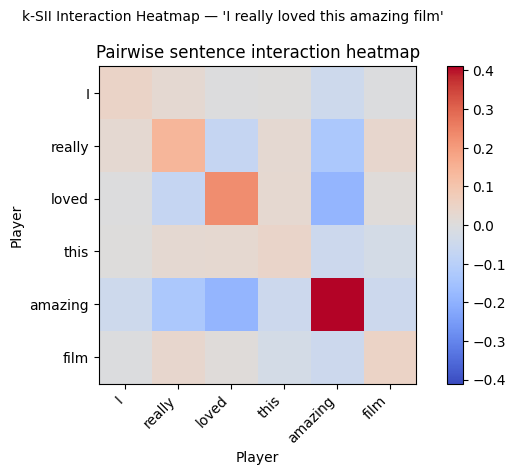

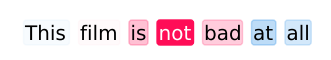

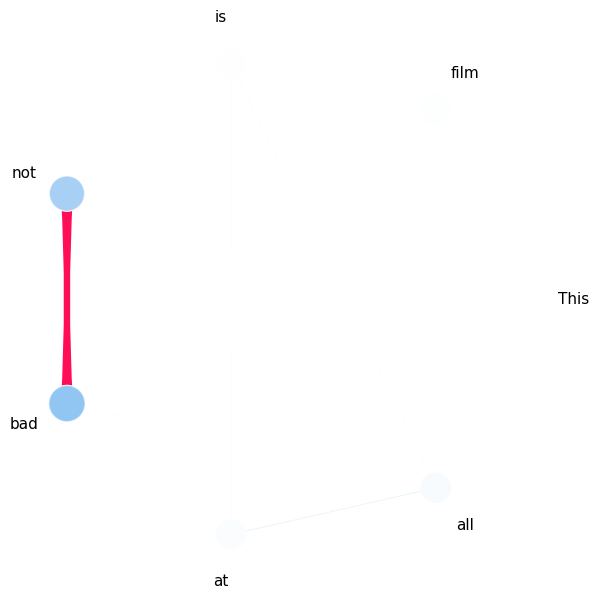

/var/folders/qr/_165pyzd2_d3dr_cj860yr3c0000gn/T/ipykernel_8284/3888178493.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [35]:
sv_neg.plot_sentence(words=words_neg)
sii_neg.plot_network(feature_names=words_neg)
fig, ax = sentence_interaction_heatmap(sii_neg, words_neg, show=False)
fig.suptitle("k-SII — 'This film is not bad at all'", fontsize=10)
fig.tight_layout()
fig.show()

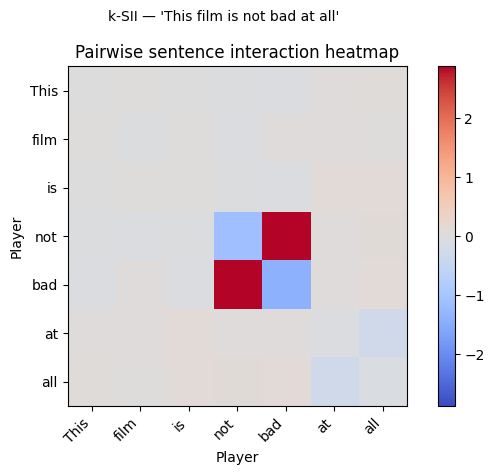

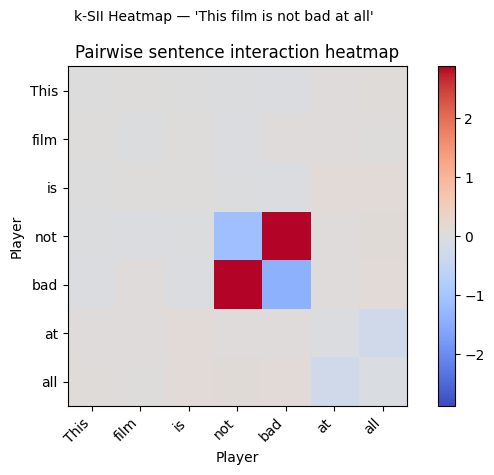

In [36]:
import matplotlib.pyplot as plt

fig, ax = sentence_interaction_heatmap(sii_neg, words_neg, show=False)
fig.suptitle("k-SII Heatmap — 'This film is not bad at all'", fontsize=10)
fig.tight_layout()
plt.show()

## Example 3: Sarcasm — "What a magnificent disaster of a film"
Here "magnificent" and "disaster" pull in opposite directions individually.
- SVs will split the sentence into positive ("magnificent") and negative ("disaster")
- But the *combination* is sarcastic — the whole phrase reads as strongly negative
- k-SII should reveal a strong

In [37]:
text_sarc = "What a magnificent disaster of a film"

imputer_sarc = TextImputer(
    MODEL_NAME,
    text_sarc,
    segmentation="word",
    mask_strategy="mask",
)

words_sarc = imputer_sarc.players.tolist()
print(f"Players  : {words_sarc}")
print(f"Baseline : {imputer_sarc.normalization_value:.4f}")

sv_sarc = shapiq.KernelSHAP(
    n=imputer_sarc.n_features, random_state=RANDOM_STATE
).approximate(budget=300, game=imputer_sarc)

print("\nShapley Values:")
for word, val in zip(words_sarc, sv_sarc.values):
    print(f"  {word:12s}: {val:+.4f}")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Players  : ['What', 'a', 'magnificent', 'disaster', 'of', 'a', 'film']
Baseline : 0.5278

Shapley Values:
  What        : +0.0000
  a           : -0.0007
  magnificent : +0.0570
  disaster    : +0.5185
  of          : -1.1149
  a           : -0.5793
  film        : +0.0440


In [38]:
sii_sarc = shapiq.KernelSHAPIQ(
    n=imputer_sarc.n_features,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
).approximate(budget=300, game=imputer_sarc)

print("Top pairwise interactions:")
order2 = {k: v for k, v in sii_sarc.interaction_lookup.items() if len(k) == 2}
sorted_interactions = sorted(order2.items(), key=lambda x: abs(sii_sarc.values[x[1]]), reverse=True)
for indices, idx in sorted_interactions[:7]:
    w1, w2 = words_sarc[indices[0]], words_sarc[indices[1]]
    val = sii_sarc.values[idx]
    print(f"  ({w1:12s}, {w2:12s}): {val:+.4f}")

/Users/montassar/shapiq-text-llm-explanations/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


Top pairwise interactions:
  (disaster    , of          ): -0.8906
  (disaster    , film        ): -0.6010
  (magnificent , disaster    ): +0.5583
  (of          , film        ): -0.5305
  (magnificent , film        ): -0.5126
  (magnificent , of          ): -0.3591
  (a           , film        ): -0.2323


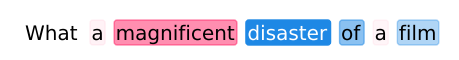

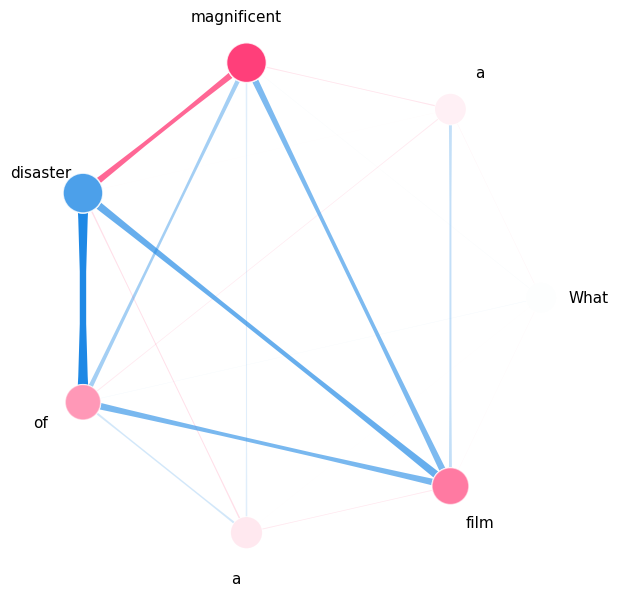

In [39]:
sv_sarc.plot_sentence(words=words_sarc)
sii_sarc.plot_network(feature_names=words_sarc)

## Conclusions

### What we found across three examples

| Example | Key SV finding | Key k-SII finding |
|---|---|---|
| "I really loved this amazing film" | "film" and "this" dominate | "loved"+"amazing" are redundant (negative interaction) — diminishing returns |
| "This film is not bad at all" | "bad" = +0.316, "not" = +0.081 — misleading | (not, bad) = +2.878 — the pair is the signal, SVs completely miss this |
| "What a magnificent disaster of a film" | Noisy — "of" dominates at -1.115 | "magnificent"+"disaster" show opposite pulls — model doesn't detect sarcasm |

### What interactions revealed that SVs missed
1. **Negation is invisible to SVs.** "not" gets a modest positive score individually.
   k-SII exposes the (not, bad) pair as the true carrier of meaning — 35x larger
   than any individual SV in that sentence.

2. **Redundancy is real.** In the positive sentence, piling up positive words
   gives diminishing returns. k-SII captures this as negative interactions
   between "loved", "really", and "amazing".

3. **Sarcasm is hard.** The model doesn't detect sarcasm — it pattern-matches
   on "disaster of a film" as a known negative construction. Neither SVs nor
   k-SII can fix a model that hasn't learned the phenomenon.
   This is an honest null result.

### Where the method breaks down
- Duplicate tokens ("a", "a") confuse word-level segmentation
- The model itself (DistilBERT/IMDb) has strong domain priors that
  override surface-level linguistic structure
- k-SII values can be very large (2.87) when interactions dominate —
  harder to interpret on an absolute scale

## Reproducibility

- **Model:** `lvwerra/distilbert-imdb` (HuggingFace)
- **Random seed:** 42
- **Budget:** 200–300 coalitions (exact for ≤7 players due to border trick)
- **Segmentation:** word-level (whitespace split)
- **Mask strategy:** `[MASK]` token replacement